In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from dynamax.hidden_markov_model import LinearAutoregressiveHMM

import pandas as pd
import numpy as np


import lissa as li

In [2]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_119579/1698806942.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [3]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

In [ ]:
X_train_jnp = jnp.array(X_train[Headers])
trainLength_jnp = jnp.array(trainLength)
X_test_jnp = jnp.array(X_test[Headers])
testLength_jnp = jnp.array(testLength)
modelData_jnp = jnp.array(modelData[Headers])
totalLength_jnp = jnp.array(totalLength)


In [7]:
# Now fit an HMM to the emissions
key1, key2 = jr.split(jr.PRNGKey(0), 2)
num_states = 2
num_lags = 4

emissions = X_train_jnp

# Initialize with K-Means
arhmm = LinearAutoregressiveHMM(num_states, modelData_jnp.shape[1], num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="prior", emissions=emissions)

inputsAR = arhmm.compute_inputs(X_train_jnp)

# # Fit with EM
fitted_params, lps = arhmm.fit_em(params, props, emissions=X_train_jnp,inputs=inputsAR,num_iters=3)

XlaRuntimeError: INTERNAL: cuSolver internal error

In [26]:
lps

Array([-7521265.,       nan,       nan], dtype=float32)

In [27]:
pumpData = jnp.array(totalData.loc[totalData["Well Run"]==pumpList[0]][Headers].to_numpy())
inputsAR_pump = arhmm.compute_inputs(pumpData)


posterior = arhmm.smoother(fitted_params, pumpData, inputs=inputsAR_pump)

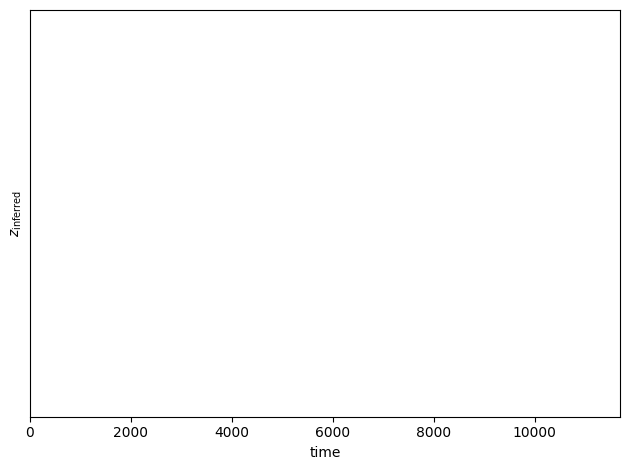

In [28]:
plt.imshow(posterior.smoothed_probs.T, aspect="auto", interpolation="none", cmap="Greys", vmin=0, vmax=1)

plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")

plt.tight_layout()

In [ ]:

li.PostProcessing(modelFull, totalData, modelData, Headers, "Full States", totalLength)
print(modelFull.get_stationary_distribution())
totalData["Full States"] = totalData["Full States"].map(li.StateConversion(modelFull.get_stationary_distribution(),n))



GMM BIC: 18749532.167129878
AIC: 17499994.176407393 BIC: 17502778.493150625
[0.30673424 0.06787789 0.62538787]


In [5]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [3]

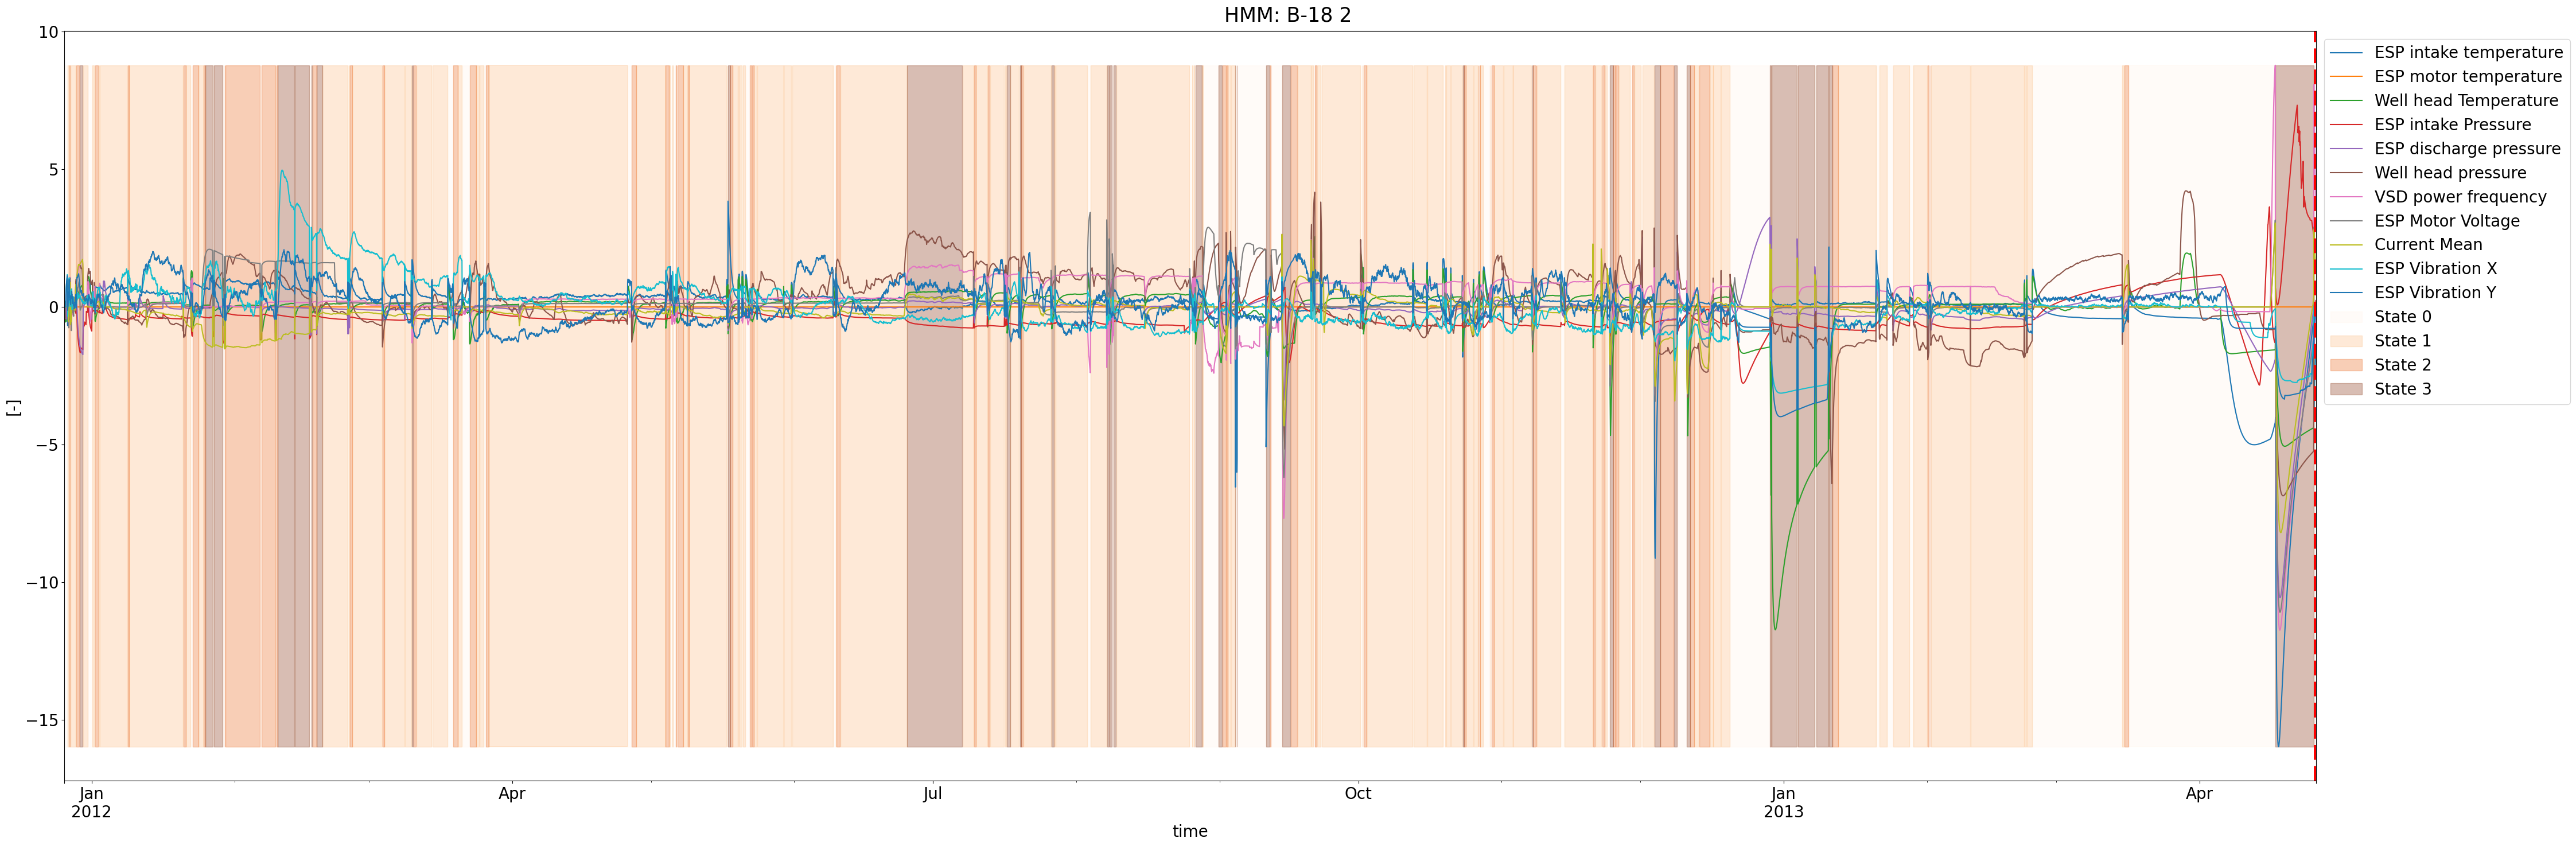

In [6]:
pump = pumpList[0]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,props=[Headers],measures='[-]',states=["Full States"], numberOfStates=n, figsize=(45,15))
plt.rcParams["font.size"]=20

#fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


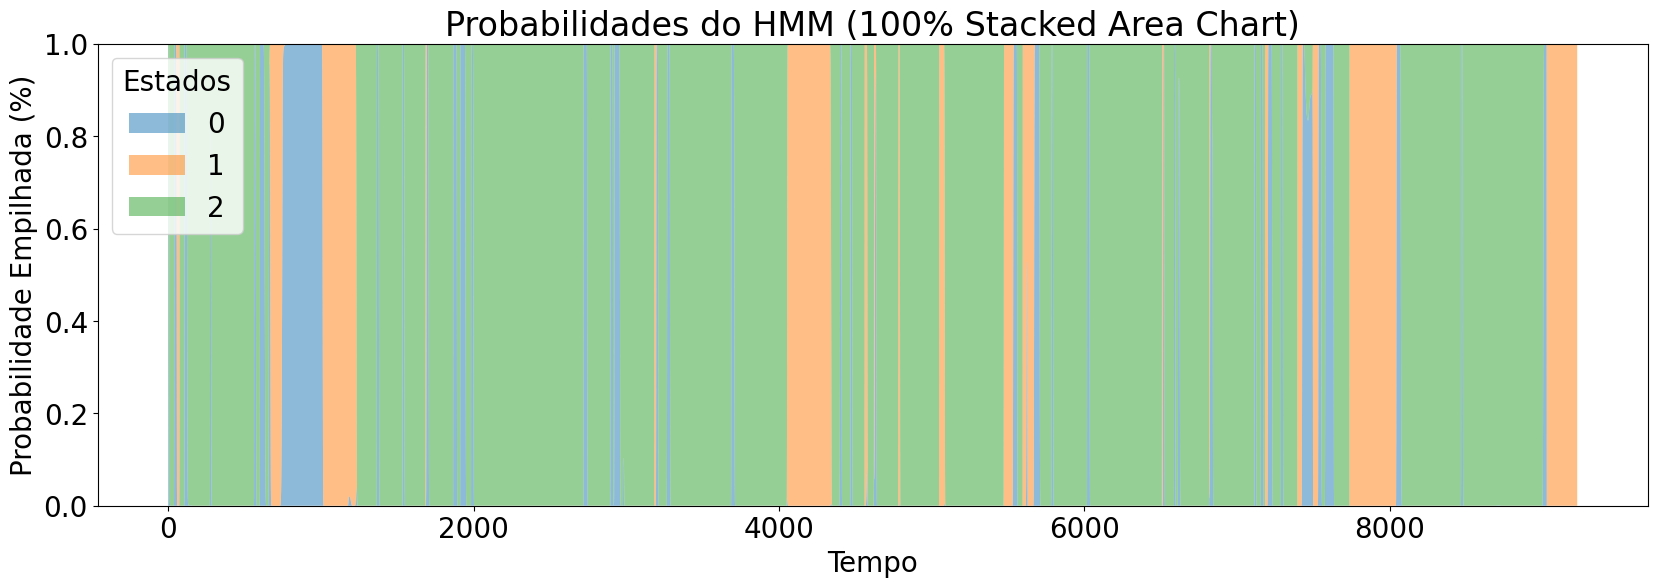

In [7]:
li.PlotHMMProbs(totalData[Headers].loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0])],modelFull)

In [8]:
modelFull.transmat_

array([[9.95137332e-01, 1.01408805e-03, 3.84858012e-03],
       [6.93578265e-03, 9.92188857e-01, 8.75360359e-04],
       [1.63220391e-03, 3.50419918e-04, 9.98017376e-01]])